## In this notebook we use RNN/GRU, Reservior computing, Next-Generation Reservior computing to study the damped oscillator system we studied in tutorial 3 again. 

The code for RNN,RC and NGRC is provided by ChatGPT modified by Gang Xu for PSI scientific machine learning course.
We also use some of Ben Moseley's code for normal NN and pretty plotting

### Import libraries <span style="color:blue">(no need to change)

In [45]:
import numpy as np
import torch as tc
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np #provide
from scipy.integrate import solve_ivp 
import matplotlib.pyplot as plt 
import time

### Same parameters as before

In [46]:
# Parameters
gamma = 0.1        # damping
omega0 = 1.0       # natural frequency
x0 = 1.0           # initial position
v0 = 0.0           # initial velocity
tscale=20.0  # scale factor for time
###############################3
density = 1 ## every density number of data, one is used you may change later
################################################3

### Solve the system using solve_ivp just as before <span style="color:blue">(no need to change)

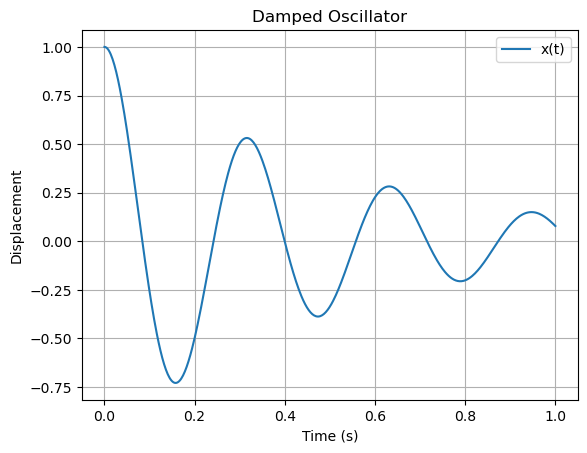

In [47]:
# Time span
T_Total = 500
t_span = (0/tscale, 20/tscale)           # from 0 to 1 seconds (adjusted time)
t_eval = np.linspace(0, 20, T_Total)/tscale  # points to evaluate

# Define first-order system
def damped_oscillator(t, y):
    x, v = y
    dxdt = v
    dvdt = -2*gamma*v*tscale - omega0**2 * x*tscale**2
    return [dxdt, dvdt]

# Solve IVP
sol = solve_ivp(damped_oscillator, t_span, [x0, v0], t_eval=t_eval)
x=tc.from_numpy(sol.t).unsqueeze(1).float()


y=tc.from_numpy(sol.y[0]).unsqueeze(1).float()

x_data = x[0:500:density]
y_data = y[0:500:density]

tpts= T_Total // density #only one out of every density # of data are used
t_total = tc.linspace(0, 20, tpts)
# Plot
plt.plot(x,y , label="x(t)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement")
plt.title("Damped Oscillator")
plt.grid(True)
plt.legend()
plt.show()

### Split data for training and reshape it to the shape to be used by RNN

In [48]:
##############################################3
train_ratio = 0.4 ### can adjust this parameter
##################################################3
T_train = int(tpts * train_ratio)
t_train = t_total[:T_train]
train_traj = y_data[:T_train]
test_traj = y_data[T_train:]
input_seq = train_traj[:-1].view(-1,1,1)  #this remove the last element as the last element will have no target to compare to
# [seq_len, batch, input_size] in the standard RNN input format, batch indicates we only input one sequence, and input_size indicate that our feature is 1d.
target_seq = train_traj[1:].view(-1,1,1) #removes first element, as it has no input

### Define simple RNN

In [55]:

class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=15, output_size=1):
        super().__init__()
        ######################
        self.rnn = nn.GRU(input_size, hidden_size, batch_first=False) #defines a RNN and then GRU (gated recurrent unit, a type of RNN) use a sequence of data as input_seq, the shape is batch not first
   # change to GNU later   
    ###########################
        self.fc = nn.Linear(hidden_size, output_size) #### fully connected layer on top GRU, standard NN layer
        
    def forward(self, x, h0=None):### forward pass function , automatically called when use model() x, input sequence in the shape of input_seq h0=None defaults initial hidden states to zeros
        out, hn = self.rnn(x, h0) ### self.rnn is the nn.GRU layer, x is input_seq output has the information about hidden states at all times of shape seq_len, batch, hidden_size
        ###out[t,:,:] has hidden state at time t hn are the hidden states at the last time step for each layer 
        out = self.fc(out)## connects the hidden states to final prediction this change the shape from len, batch, hidden_size to len, batch, output_size (1 in our case)
        return out, hn



### Train with teacher forcing 

Epoch 100, Loss: 0.000287


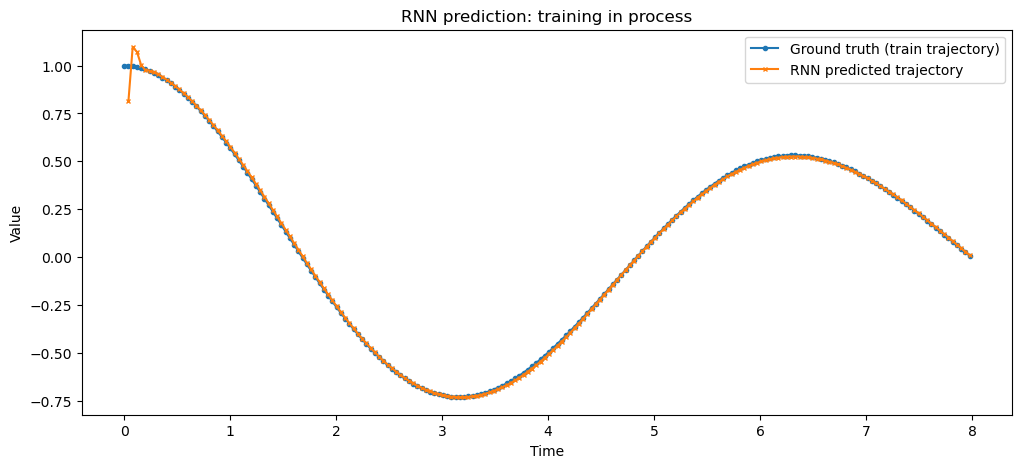

Epoch 200, Loss: 0.000066


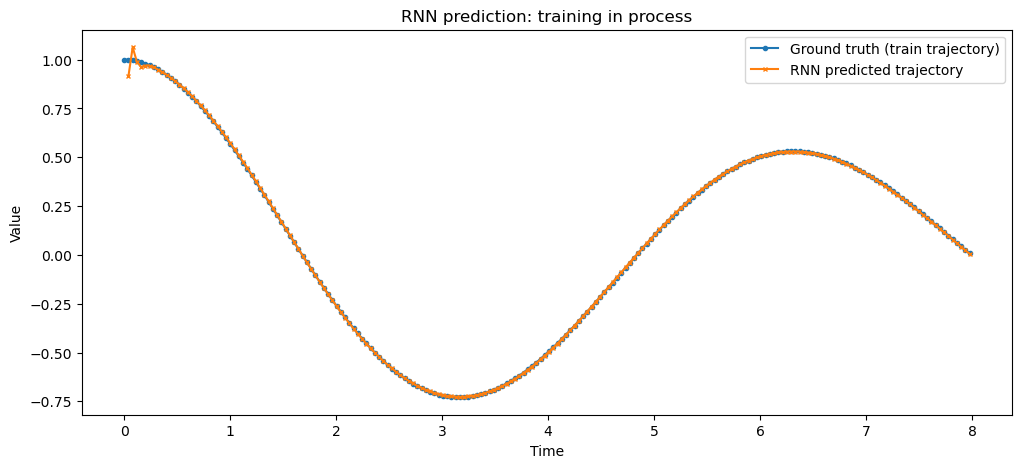

Epoch 300, Loss: 0.000014


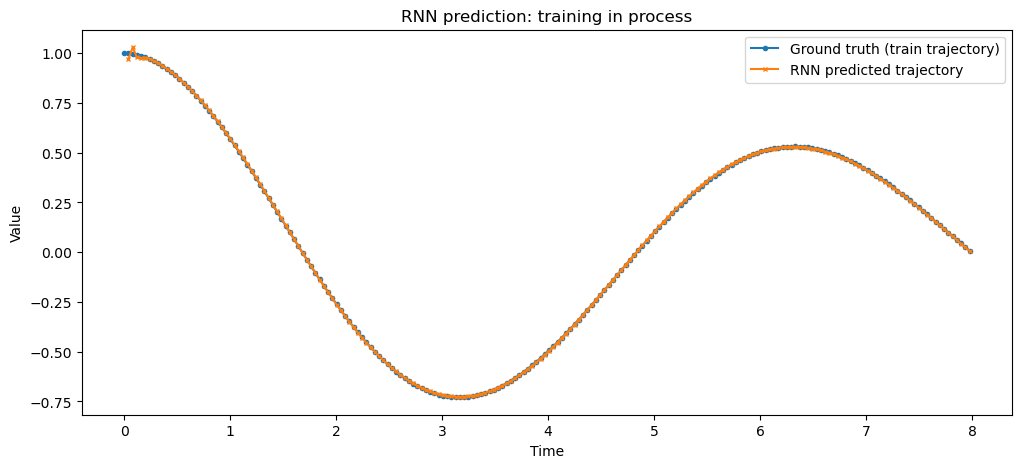

Epoch 400, Loss: 0.000003


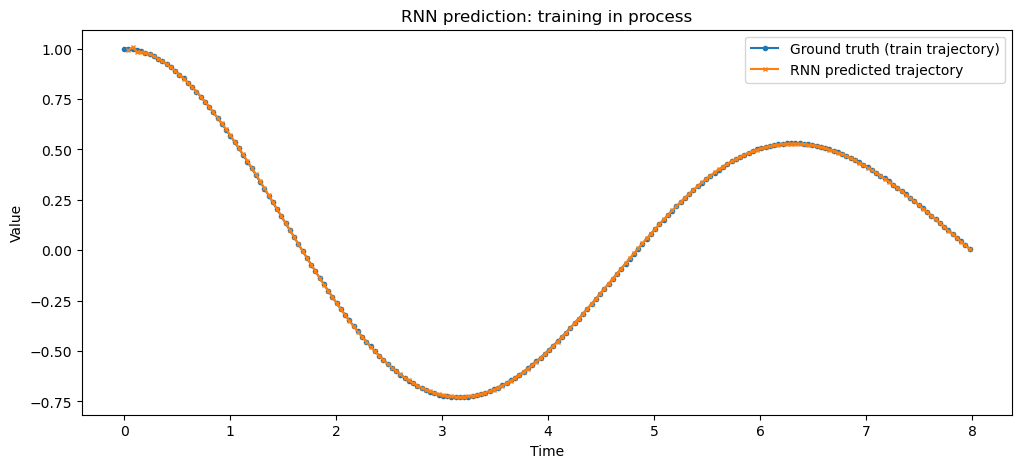

Epoch 500, Loss: 0.000002


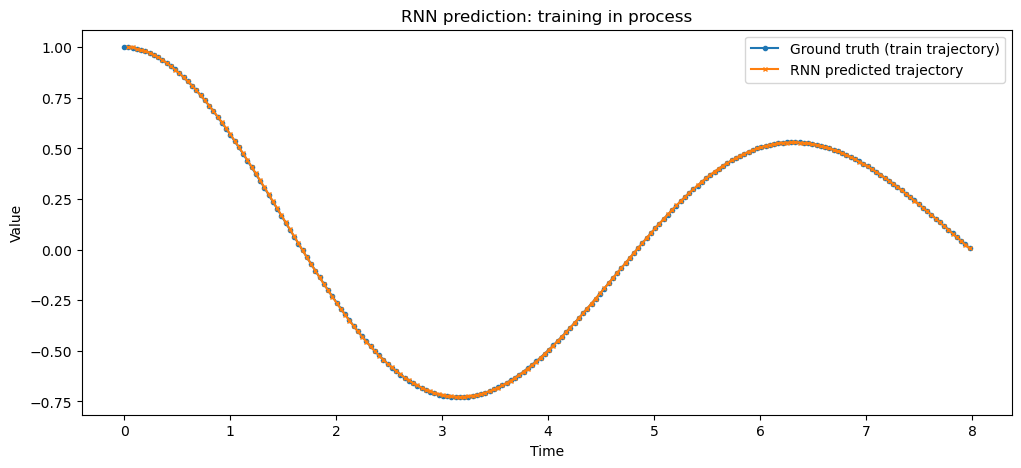

Epoch 600, Loss: 0.000001


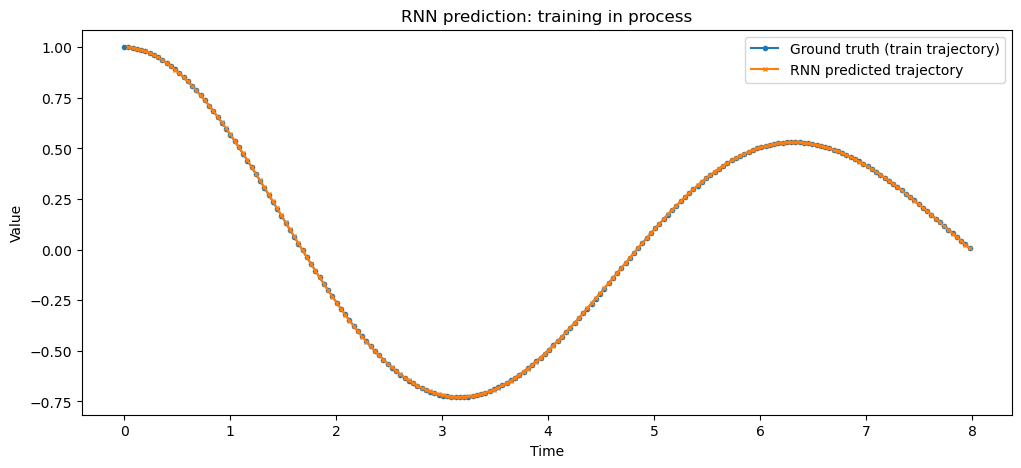

Epoch 700, Loss: 0.000001


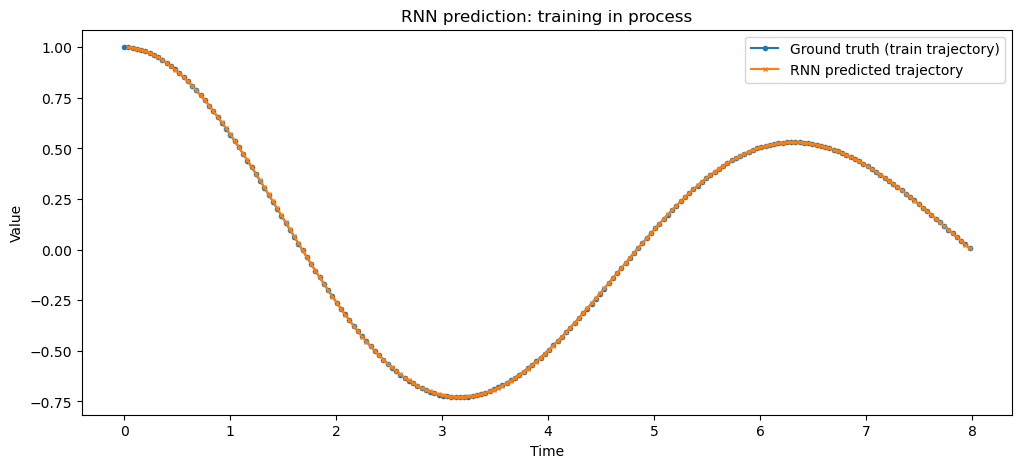

Epoch 800, Loss: 0.000001


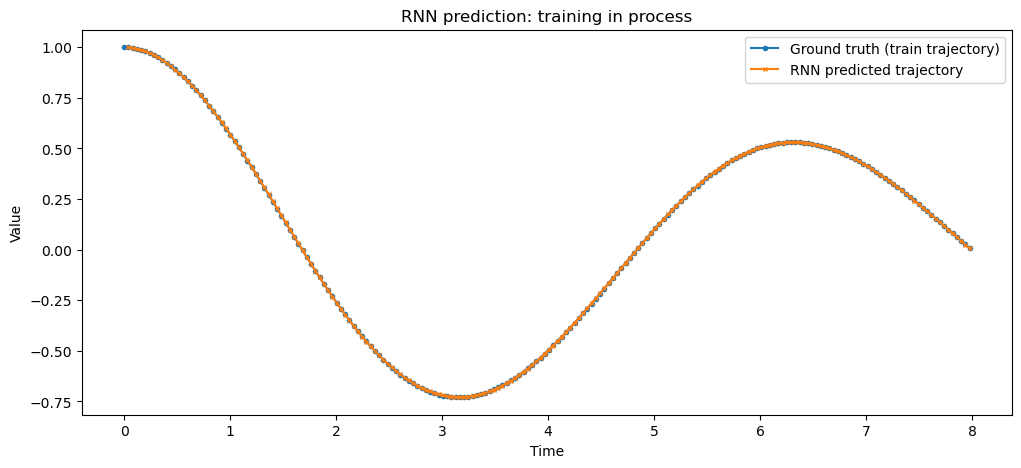

Epoch 900, Loss: 0.000001


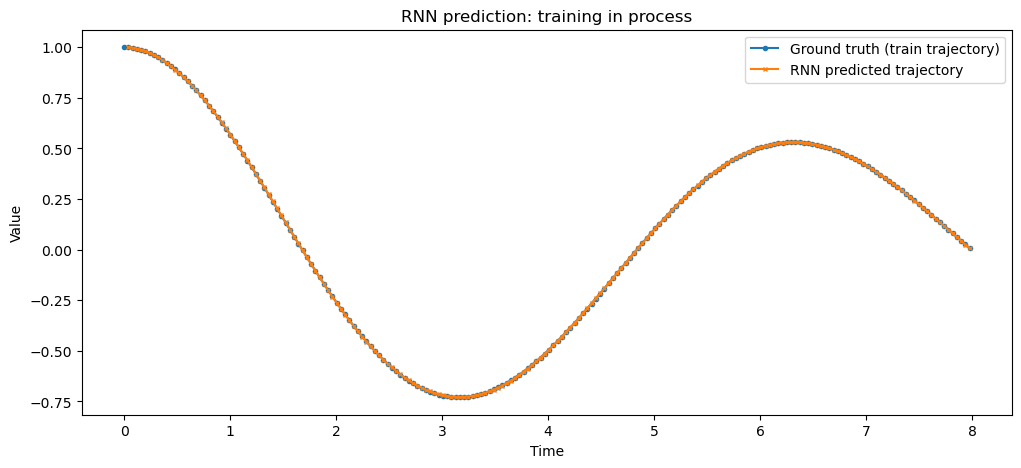

Epoch 1000, Loss: 0.000000


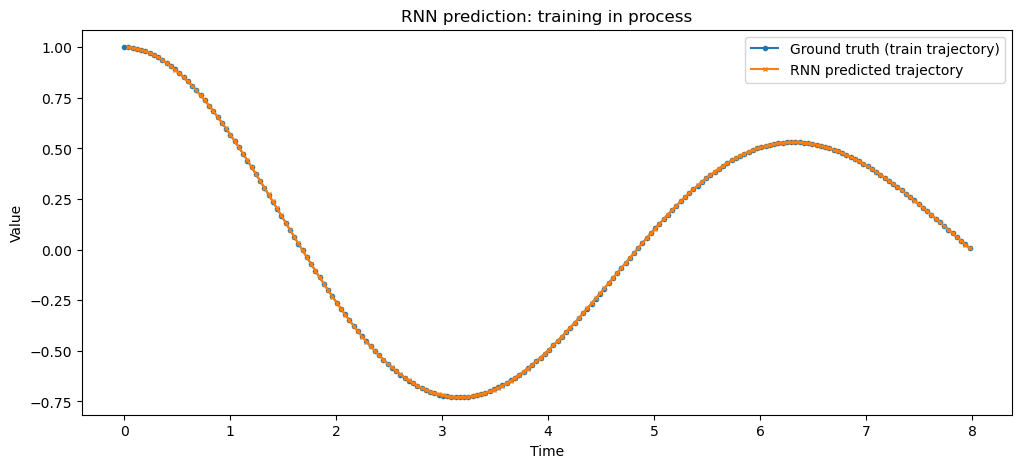

In [56]:
model = SimpleRNN()
criterion = nn.MSELoss()
#####################################################################33
optimizer = tc.optim.Adam(model.parameters(), lr=0.01) ###  can change learning rate
################################################################################
epochs = 1000 ### can change number of epoch
##################################################################333
for epoch in range(epochs):
    optimizer.zero_grad() ## reset gradient to zero
    output, _ = model(input_seq) ## equivalent to output, h = model(input_seq, h) 
    loss = criterion(output, target_seq) ## calculate loss
    loss.backward()
    optimizer.step()
    ###########################################3
    if (epoch+1) % 100 == 0:   ######may change how often to see loss and plot
    ################################################3    
        print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")
        plt.figure(figsize=(12,5))
        plt.plot(t_train, train_traj, label='Ground truth (train trajectory)', marker='o', markersize=3)
        plt.plot(t_train[1:], output[:,0,0].detach().numpy(), label='RNN predicted trajectory', marker='x', markersize=3)
     #   plt.axvline(x=t_total[T_train-1], color='r', linestyle='--', label='End of training data')
        plt.xlabel("Time")
        plt.ylabel("Value")
        plt.title("RNN prediction: training in process")
        plt.legend()
        plt.show()

### Free rollout to predict the entire trajectory

In [57]:
#model.eval() ### eval is inherited from nn.module switch model to evaluation mode 

inp = input_seq[0].view(1,1,1)  # start with first training point # notice that input size is 1 now, not a sequence
pred = []
h = None
total_steps = tpts - 1  # predict entire trajectory from first point

for _ in range(total_steps): ### notice loop over the steps in the future
   ########################################################
      out, h = model(inp, h)             
      ##### student code to implement free rollout 
      ### notice that loss.backward or optimizer.step() is not called the weights will not change still stored in the memory

      inp = out 
      pred.append(out.item())
    ###########################################################3
                     ##### student code to implement free rollout
    ##################################################

### Plot the ground truth and RNN prediction<span style="color:blue">(no need to change)

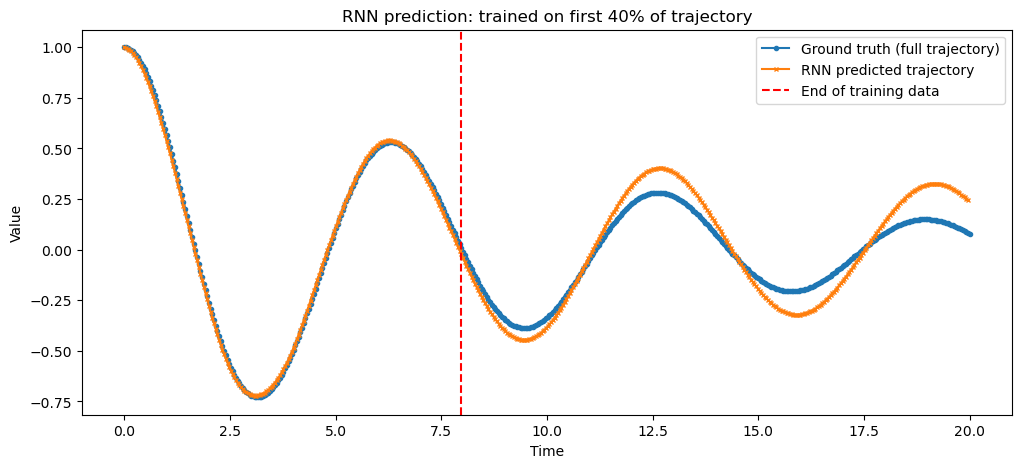

In [58]:
plt.figure(figsize=(12,5))

plt.plot(t_total, y_data, label='Ground truth (full trajectory)', marker='o', markersize=3)
plt.plot(t_total[:-1], pred, label='RNN predicted trajectory', marker='x', markersize=3)
plt.axvline(x=t_total[T_train-1], color='r', linestyle='--', label='End of training data')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("RNN prediction: trained on first 40% of trajectory")
plt.legend()
plt.show()

### Write a code to plot the error grows as time

<function matplotlib.pyplot.show(close=None, block=None)>

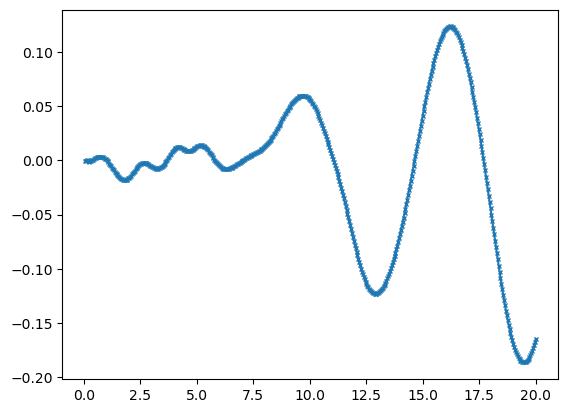

In [59]:
tpred = tc.from_numpy(np.array(pred)).unsqueeze(1).float() ####### remember pred and y_data are not same type.
###################
y_data_list = np.array([y_data[i].item() for i in range(1, 500)])
pred = np.array(pred)

error = (y_data_list - pred)
plt.plot(t_total[1:], error, label='error grows as time', marker='x', markersize=3) ##### student code here
#######################e
plt.show

### Remember our normal neural network? Maybe we did not feed enough training data. let us try again <span style="color:blue">(no need to change)

In [60]:
class FCN(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

In [61]:
def plot_result(x,y,x_data,y_data,yh,xp=None):
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="grey", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    if xp is not None:
        plt.scatter(xp, -0*tc.ones_like(xp), s=60, color="tab:green", alpha=0.4, 
                    label='Physics loss training locations')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off")

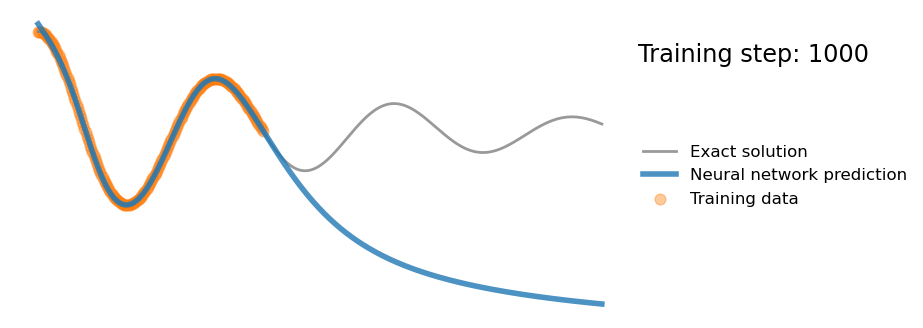

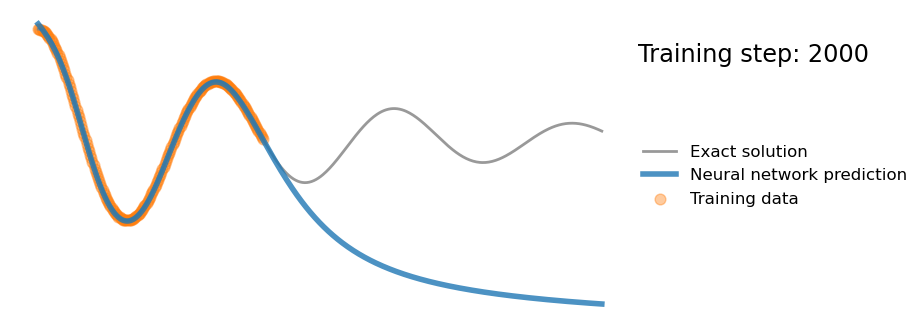

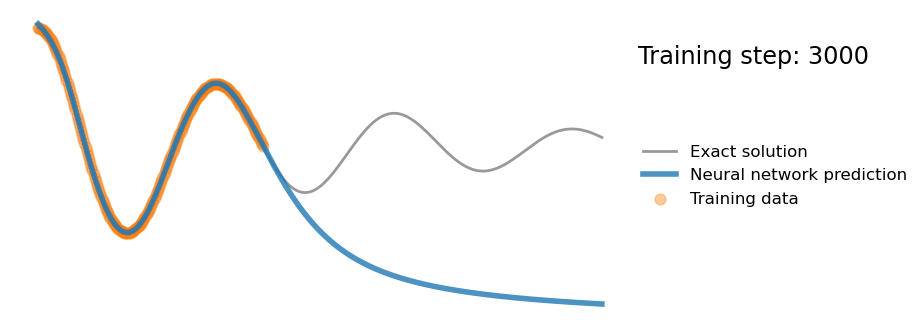

In [62]:
x_data_train=x_data[:T_train]
y_data_train=y_data[:T_train]
# train standard neural network to fit training data
tc.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = tc.optim.Adam(model.parameters(),lr=1e-3)
files = []
for i in range(3000):
    optimizer.zero_grad()
    yh = model(x_data_train)
    loss = tc.mean((yh-y_data_train)**2)# use mean squared error
    loss.backward()
    optimizer.step()
    
    
    # plot the result as training progresses
    if (i+1) % 1000 == 0: 
        
        yh = model(x).detach()
        plot_result(x,y,x_data_train,y_data_train,yh)
        
    
        plt.show()
        


## Define a Reservoir 
Reservoir update its state with
$$
h_{t+1}=tanh(Wh_t+W_{in}x_t)
$$

In [87]:
class Reservoir:
    ###############################################################################
    def __init__(self, input_size=1, reservoir_size=50, spectral_radius=0.9): ### input_size: 1d 200 internal neurons unless specified
        ##############you may want to change reservoir_size later
        ###########################################################################################
        ##### spectral_radius is the largest eigenvalue magnitude of the reservoir weight matrix. needs to be smaller than 1 to have stable dynamics. 
        self.N = reservoir_size
        
        self.Win = np.random.randn(self.N, input_size) * 0.5 ### initialize the input weight matrix with shape (200,1) in our case
        W = np.random.randn(self.N, self.N)### initialize W to be (200,200), this is the reservoir matrix 
        
        # scale to desired spectral radius
        eigvals = np.linalg.eigvals(W)
        W = W* spectral_radius / np.max(np.abs(eigvals)) ###make sure the largest eigenvalue magnitude of the reservoir weight matrix stay under the spectral_radius
        
        self.W = W ##now other methods can access it
        
    def run(self, x): ######## x is the input 
        T = len(x) # number of time series
        h = np.zeros((self.N,)) ### initiate a 1D array reservoir state
        states = []
        
        for t in range(T):
            h = np.tanh(self.W @ h + self.Win @ np.array([x[t]]))
            ### note that we don't train the weights, the weights are fixed random reservoir
            states.append(h.copy()) ### create a separate copy so later update does not change states
            
        return np.array(states)

### Now run the reservoir on the trajectory <span style="color:blue">(no need to change)

(200,)
training error 0.0004008823469389562


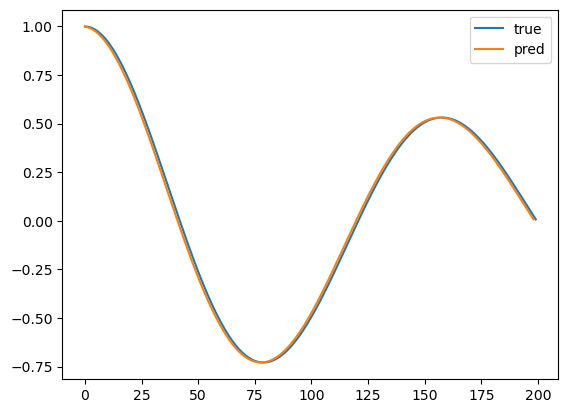

In [88]:
# Make sure train_traj_np is 1D
train_traj_np = train_traj.detach().numpy().squeeze()  # shape (200,)
print(train_traj_np.shape)
res=Reservoir()
# Run the reservoir on the training trajectory
states = res.run(train_traj_np[:-1])  # assume res.run outputs shape (time_steps, N_reservoir)
Y_target = train_traj_np[1:]         # target is next step

# Linear regression readout
Wout = np.linalg.pinv(states) @ Y_target.reshape(-1,1) ##### computes the pseudoinverse of the matrix states it gives the least square solution for Wout@states= Y_target
pred_train = states @ Wout  # just linear readout on recorded (trained) states
plt.plot(train_traj_np, label="true")
plt.plot(pred_train, label="pred")
plt.legend()
mse=np.mean((pred_train.flatten()-train_traj_np[:-1].flatten())**2)
print("training error", mse)

### Free rollout prediction

In [89]:

# Prepare for prediction
h=states[-1, :].reshape(-1, 1)  # last state, column vector (200,1)
inp= train_traj_np[-1].reshape(1, 1)  # last input as column vector
#print(res.W.shape)
#print(res.Win.shape)
#print(Wout.shape)
#print(h.shape)
#print(inp)


pred_rc = []

for _ in range(60):
    
    #################################################3
    h =  np.tanh(res.W @ h + res.Win @ inp)
    # (200,1) ######################student update h
    ########################################################
    
    ##########################################################3
    out = Wout.T @ h 
    # Wout.T shape (1,200) -> out (1,1) ##################student compute output
    ###############################################################
    pred_rc.append(out[0,0].item())  # store as scalar
    
  
    ####################################################################
    inp = out 
    #shape (1,1) ###################student code next input
    #####################################################################
    # print(inp.shape)
# Convert predictions to a 1D array
pred_rc = np.array(pred_rc)  # shape (len(test_traj),)


### Comparision of rollout of RC and ground truth <span style="color:blue">(no need to change)

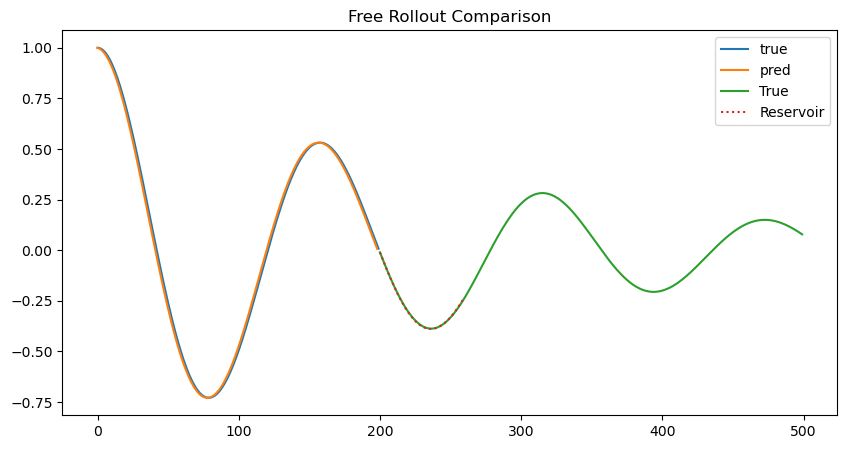

In [90]:
test_traj_np=test_traj.detach().numpy().squeeze()

pred_rc_np=np.array(pred_rc)
size = len(test_traj_np)
sizep = len(pred_rc_np)
tplt =200+np.arange(size)
tplt_rc= 200+np.arange(sizep)
plt.figure(figsize=(10,5))
plt.plot(train_traj_np, label="true")
plt.plot(pred_train, label="pred")
plt.plot(tplt,test_traj_np, label="True")
#plt.plot(pred_gru, '--', label="GRU")
plt.plot(tplt_rc, pred_rc_np,  ':', label="Reservoir")
plt.legend()
plt.title("Free Rollout Comparison")
plt.show()

#print("GRU train time:", gru_train_time)
#print("Reservoir train time:", rc_train_time)

## Next-generation Reservoir computing

### Same oscillator data

In [110]:
##############################################
density = 1 # one out of every density # of points is used can adjust this parameter
################################################
x = sol.y[0]
x_data = x[0:500:density]
noise = np.random.uniform(-0.1, 0.1, 500)
data= x_data + noise 
######################################


###########later you may want to add code to include some noise

###########################################3
# shape (N,2) First row x second row v

### train/test split

In [111]:
##########################
train_fraction = 0.4 ### may want to change this parameter
######################################
split_index = int(len(data) * train_fraction)

train_data = data[:split_index] ### (0.4*N, 2)

### Build NGRC features 

In [112]:
def poly_features(X):
    T = X.shape[0]  ### T is the timestep, n is 2 x and v
    features = []
    for t in range(T-2):
        x_t = X[t]
        next_x = X[t+1]### at each step x_t contains x and v at that time step
        feat = list([x_t, next_x, x_t*x_t,next_x*next_x,x_t*next_x]) 
        features.append(feat)# turn x_t into a list x and v
    return np.array(features)

### Compute Wout

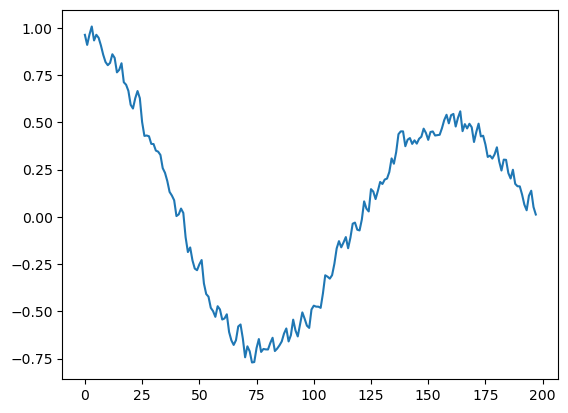

In [113]:
features_train = poly_features(train_data)
Y_target = train_data[2:]  # predict x
############################################################################
Wout = np.linalg.pinv(features_train) @ Y_target.reshape(-1,1)
### student code solve features*Wout=Y_target code here
#####################################################################################3
test= features_train @ Wout
plt.plot(test)
###################################################################################

### Rollout prediction

In [114]:
#data.shape[0]-1
X_pred = []
previous = data[0]
current = data[1]
for u in range(len(data)-2):
    feat = list([previous, current, previous*previous,current*current,previous*current]) ###this is a pair of x,v
    feature = np.array(feat)
    ###################################################
    y_hat = (feature @ Wout)[0]   
    ####use features*Wout to predict 
    #####################################################
    X_pred.append(y_hat)
    previous = current
    current = y_hat

X_pred = np.array(X_pred)
#print(y_hat)
#print(feature)
#Wout

### plot<span style="color:blue">(no need to change)

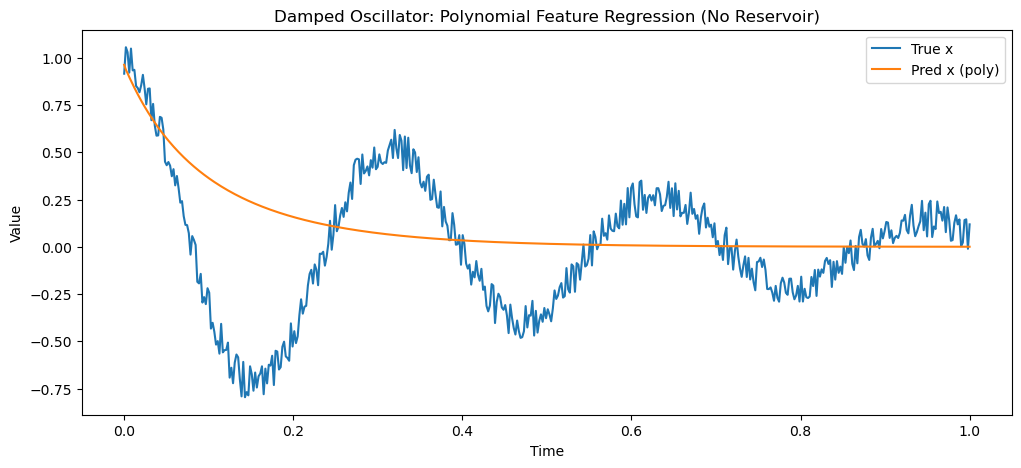

In [115]:
t = np.linspace(0, 20, len(X_pred))/tscale
plt.figure(figsize=(12,5))
plt.plot(t, data[2:], label="True x")
plt.plot(t, X_pred, label="Pred x (poly)")
#plt.plot(t, data[:,1], label="True v")
#plt.plot(t, X_pred[:,1], label="Pred v (poly)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.title("Damped Oscillator: Polynomial Feature Regression (No Reservoir)")
plt.show()

In [ ]:
# not robust against noise 